
# Multicollinearity, Homoscedasticity, and Regularization (Ridge, Lasso, Elastic Net)

This notebook demonstrates:

1. Create your own dataset
2. Detecting **Multicollinearity**
3. Checking **Homoscedasticity**
4. Applying **Ridge Regression**
5. Applying **Lasso Regression**
6. Applying **Elastic Net Regression**
7. Comparing model performance



## Step 1: Import Libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error


## Step 2: Create Synthetic Dataset

In [3]:

np.random.seed(42)

n = 200

X1 = np.random.normal(0,1,n)
X2 = X1 * 0.9 + np.random.normal(0,0.1,n)
X3 = np.random.normal(0,1,n)

noise = np.random.normal(0,1,n)

y = 3*X1 + 2*X2 + 1.5*X3 + noise

df = pd.DataFrame({
    "X1":X1,
    "X2":X2,
    "X3":X3,
    "y":y
})

df.head()


,X1,X2,X3,y
0,0.496714,0.482821,-1.594428,0.821133
1,-0.138264,-0.068359,-0.599375,-2.372740
2,0.647689,0.691225,0.005244,4.202987
3,1.523030,1.476107,0.046981,8.947412
4,-0.234153,-0.348505,-0.450065,-1.661133


## Step 3: Correlation Matrix (Detect Multicollinearity)

In [4]:

df.corr()


,X1,X2,X3,y
X1,1.000000,0.993344,-0.134197,0.917745
X2,0.993344,1.000000,-0.135601,0.913009
X3,-0.134197,-0.135601,1.000000,0.209288
y,0.917745,0.913009,0.209288,1.000000



If two features have correlation close to **1 or -1**, it indicates **multicollinearity**.
Observe the correlation between **X1 and X2**.


## Step 4: Train Test Split

In [5]:

X = df[['X1','X2','X3']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


## Step 5: Linear Regression

In [6]:

lr = LinearRegression()
lr.fit(X_train,y_train)

pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test,pred))
print("MSE:", mean_squared_error(y_test,pred))

print("Coefficients:", lr.coef_)


R2 Score: 0.9546818143914098
MSE: 0.8604338797944827
Coefficients: [4.63874823 0.29064335 1.58678063]


Text(0, 0.5, 'Coefficient for X2')

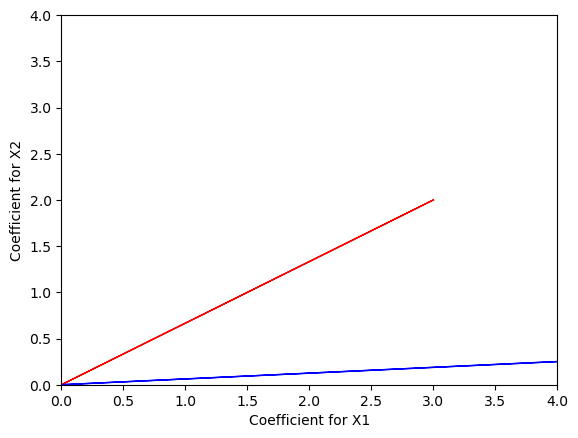

In [7]:
plt.arrow(0,0,3,2,color='r',label='True Coefficients')
plt.arrow(0,0,lr.coef_[0],lr.coef_[1],color='b',label='Estimated Coefficients')
plt.xlim(0,4)
plt.ylim(0,4)
plt.xlabel('Coefficient for X1')
plt.ylabel('Coefficient for X2')

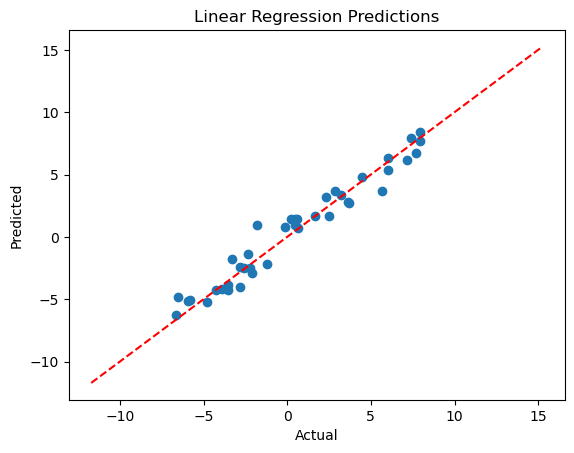

In [8]:
plt.plot(y_test.values, pred, 'o')
plt.plot([y.min(), y.max()], [y.min(), y.max()],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.show()


Because **X1 and X2 are highly correlated**, linear regression coefficients may become unstable.
This is a classical **multicollinearity problem**.


## Step 6: Check Homoscedasticity

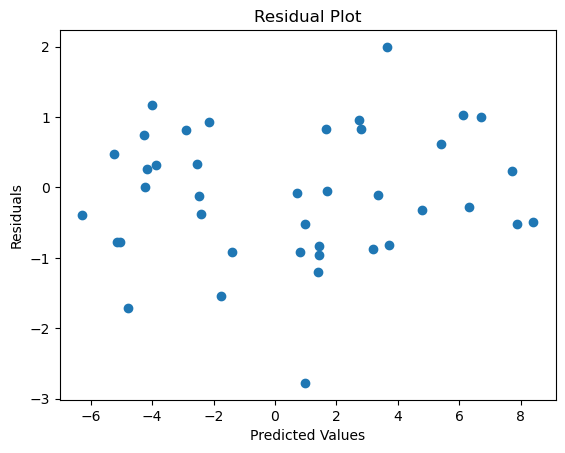

In [9]:

residuals = y_test - pred

plt.scatter(pred,residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



If residuals are randomly scattered around zero → **Homoscedasticity**.

If pattern or funnel shape appears → **Heteroscedasticity**.


## Step 7: Ridge Regression

In [10]:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test,ridge_pred))
print("Ridge MSE:", mean_squared_error(y_test,ridge_pred))
print("Ridge Coefficients:", ridge.coef_)


Ridge R2: 0.9572029067988621
Ridge MSE: 0.8125671505260137
Ridge Coefficients: [3.51864805 1.48959198 1.57663901]



Ridge Regression penalty:

||y - ŷ||² + λΣβ²

It shrinks coefficients but **does not remove features**.


## Step 8: Lasso Regression

In [11]:

lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test,lasso_pred))
print("Lasso MSE:", mean_squared_error(y_test,lasso_pred))
print("Lasso Coefficients:", lasso.coef_)


Lasso R2: 0.9510216094864377
Lasso MSE: 0.929928372235748
Lasso Coefficients: [4.77658381 0.         1.47094445]



Lasso penalty:

||y - ŷ||² + λΣ|β|

Lasso can **set coefficients to zero**, performing **feature selection**.


## Step 9: Elastic Net Regression

In [12]:

elastic = ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic.fit(X_train,y_train)

elastic_pred = elastic.predict(X_test)

print("ElasticNet R2:", r2_score(y_test,elastic_pred))
print("ElasticNet MSE:", mean_squared_error(y_test,elastic_pred))
print("ElasticNet Coefficients:", elastic.coef_)


ElasticNet R2: 0.9529338984559834
ElasticNet MSE: 0.8936206914392208
ElasticNet Coefficients: [2.76018451 2.09709712 1.44203846]



Elastic Net combines **Ridge and Lasso penalties**.

Useful when many **correlated predictors exist**.


## Step 10: Model Comparison

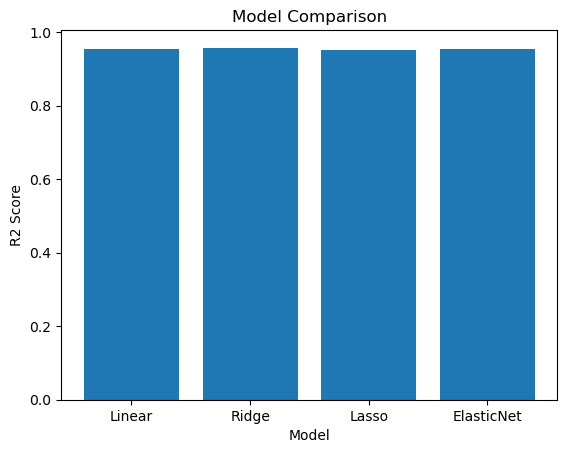

In [13]:

models = ["Linear","Ridge","Lasso","ElasticNet"]

scores = [
r2_score(y_test,pred),
r2_score(y_test,ridge_pred),
r2_score(y_test,lasso_pred),
r2_score(y_test,elastic_pred)
]

plt.bar(models,scores)
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()
